# Linear Regression from Scratch — Global Pollution & GDP

Using only Numpy, I intend to predict the following:
**can pollution and energy data predict how wealthy a country is?**

**Target variable:** `GDP_Per_Capita (in USD)`  
**Features used:** top 5 features by correlation with the target  
**Dataset:** 200 countries, 2000–2019

> **I am utilizing two methods for this to compare side by side:**
> - **Normal Equation** — solves for the optimal weights analytically in one matrix operation. Exact, instant, but can struggle with very large datasets.
> - **Gradient Descent** — iteratively nudges the weights toward lower loss. Slower but scales well.

In [1]:
from google.colab import files
uploaded = files.upload()

Saving Global_Pollution_Analysis.csv to Global_Pollution_Analysis.csv


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': '#f7f7f7',
    'axes.grid': True,
    'grid.alpha': 0.35,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.family': 'sans-serif',
    'font.size': 11
})

BLUE   = '#2E86AB'
ORANGE = '#E07A5F'
GREEN  = '#3D9970'
PURPLE = '#7B5EA7'

FEATURES = [
    'Renewable_Energy (%)',
    'Energy_Consumption_Per_Capita (in MWh)',
    'Soil_Pollution_Index',
    'Plastic_Waste_Produced (in tons)',
    'Industrial_Waste (in tons)',
]
SHORT_NAMES = ['Renewable\nEnergy', 'Energy\nConsumption', 'Soil\nPollution', 'Plastic\nWaste', 'Industrial\nWaste']
TARGET = 'GDP_Per_Capita (in USD)'

df = pd.read_csv('Global_Pollution_Analysis.csv')
X  = df[FEATURES].values
y  = df[TARGET].values

print(f'Dataset loaded: {X.shape[0]} rows, {X.shape[1]} feature columns')
print(f'Target range:   ${y.min():,.0f}  –  ${y.max():,.0f}')
df[FEATURES + [TARGET]].describe().round(2)

Dataset loaded: 200 rows, 5 feature columns
Target range:   $1,299  –  $69,143


,Renewable_Energy (%),Energy_Consumption_Per_Capita (in MWh),Soil_Pollution_Index,Plastic_Waste_Produced (in tons),Industrial_Waste (in tons),GDP_Per_Capita (in USD)
count,200.00,200.00,200.00,200.00,200.00,200.00
mean,27.80,9.44,76.49,24492.89,52891.68,35307.60
std,12.36,5.58,39.69,14421.36,27224.49,19481.71
min,5.04,0.53,11.15,542.95,1019.37,1298.70
25%,17.70,4.58,40.89,12843.88,31201.97,19525.02
50%,29.17,9.22,78.60,24121.54,55299.15,35043.32
75%,37.07,14.00,109.21,36516.23,74805.82,51629.55
max,49.56,19.98,149.23,49852.28,99739.36,69143.14


## Visualisation — Target distribution & feature correlations

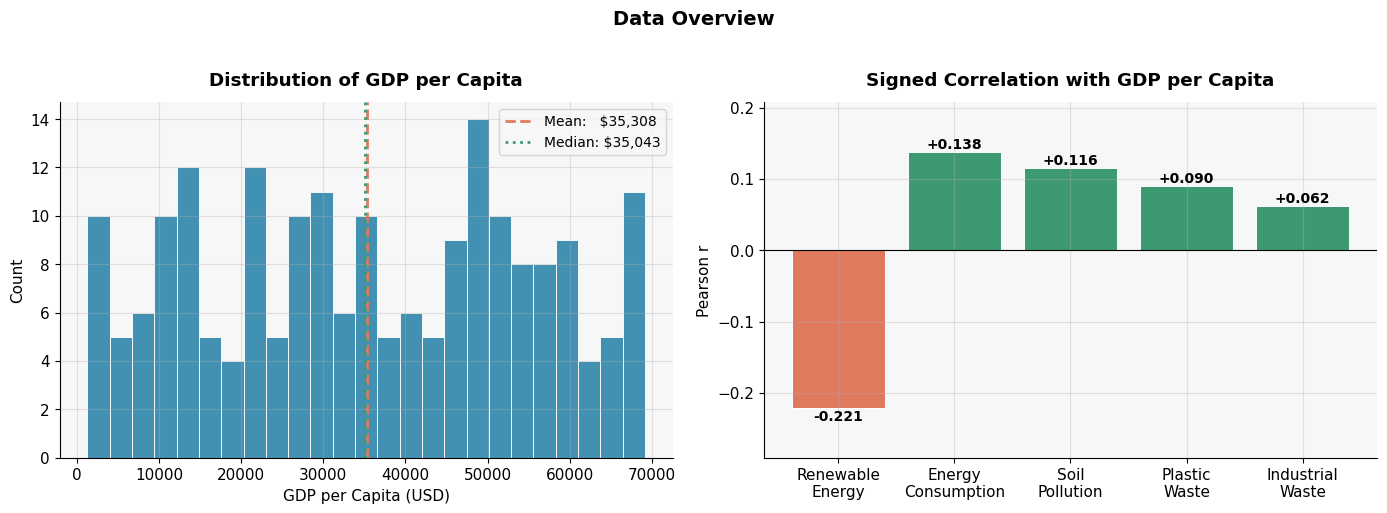


Observations:
  • GDP per capita is roughly uniform, not the bell-curve expected.
    The mean ($35k) and median are close, so there's no extreme skew.
  • Renewable Energy has the strongest correlation (negative): countries with
    more renewable energy tend to have *lower* GDP in this dataset. This likely
    reflects developing nations relying heavily on hydro/biomass := correlation ≠ causation.
  • All |r| < 0.25.



In [21]:
corrs = [np.corrcoef(df[f].values, y)[0, 1] for f in FEATURES]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# GDP distribution
axes[0].hist(y, bins=25, color=BLUE, edgecolor='white', linewidth=0.7, alpha=0.9)
axes[0].axvline(y.mean(),     color=ORANGE, linestyle='--', linewidth=2, label=f'Mean:   ${y.mean():,.0f}')
axes[0].axvline(np.median(y), color=GREEN,  linestyle=':',  linewidth=2, label=f'Median: ${np.median(y):,.0f}')
axes[0].set_title('Distribution of GDP per Capita', fontweight='bold', pad=12)
axes[0].set_xlabel('GDP per Capita (USD)')
axes[0].set_ylabel('Count')
axes[0].legend(fontsize=10)

# Signed correlations
bar_colors = [GREEN if c >= 0 else ORANGE for c in corrs]
bars = axes[1].bar(SHORT_NAMES, corrs, color=bar_colors, edgecolor='white', linewidth=0.7)
axes[1].axhline(0, color='black', linewidth=0.8)
for bar, val in zip(bars, corrs):
    ypos = val + 0.005 if val >= 0 else val - 0.018
    axes[1].text(bar.get_x() + bar.get_width() / 2, ypos, f'{val:+.3f}',
                 ha='center', fontsize=10, fontweight='bold')
axes[1].set_title('Signed Correlation with GDP per Capita', fontweight='bold', pad=12)
axes[1].set_ylabel('Pearson r')
axes[1].set_ylim(min(corrs) - 0.07, max(corrs) + 0.07)

plt.suptitle('Data Overview', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("""
Observations:
  • GDP per capita is roughly uniform, not the bell-curve expected.
    The mean ($35k) and median are close, so there's no extreme skew.
  • Renewable Energy has the strongest correlation (negative): countries with
    more renewable energy tend to have *lower* GDP in this dataset. This likely
    reflects developing nations relying heavily on hydro/biomass := correlation ≠ causation.
  • All |r| < 0.25.
""")

## Visualisation — Feature scatter plots vs GDP

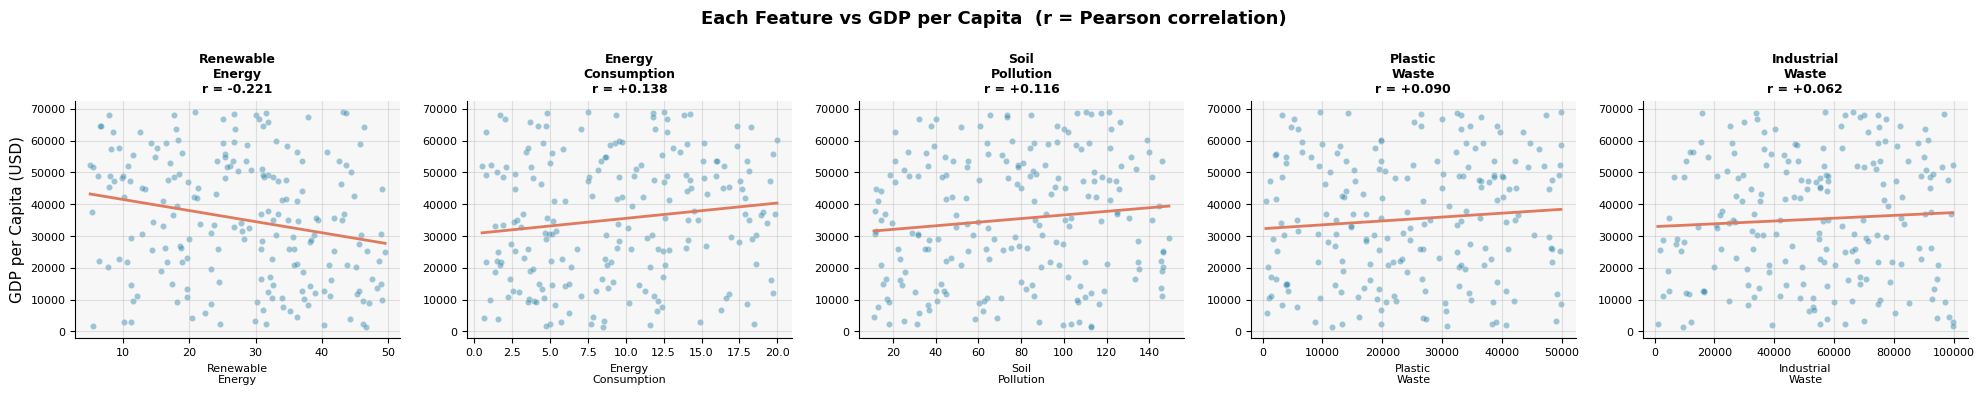


Observations:
  • Every panel shows a wide scatter cloud, visually confirming that no single
    feature is a strong predictor on its own.
  • Renewable Energy (r = −0.22) has the most noticeable slope of the five.
  • The other four are close to r = 0; their trend lines are nearly horizontal.



In [22]:
fig, axes = plt.subplots(1, 5, figsize=(20, 4))

for ax, feat, short, corr in zip(axes, FEATURES, SHORT_NAMES, corrs):
    ax.scatter(df[feat].values, y, alpha=0.45, color=BLUE, s=20, edgecolors='white', linewidth=0.3)
    m, b   = np.polyfit(df[feat].values, y, 1)
    x_line = np.linspace(df[feat].min(), df[feat].max(), 100)
    ax.plot(x_line, m * x_line + b, color=ORANGE, linewidth=2)
    ax.set_title(f'{short}\nr = {corr:+.3f}', fontsize=9, fontweight='bold')
    ax.set_xlabel(short, fontsize=8)
    ax.tick_params(labelsize=8)

axes[0].set_ylabel('GDP per Capita (USD)')
plt.suptitle('Each Feature vs GDP per Capita  (r = Pearson correlation)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("""
Observations:
  • Every panel shows a wide scatter cloud, visually confirming that no single
    feature is a strong predictor on its own.
  • Renewable Energy (r = −0.22) has the most noticeable slope of the five.
  • The other four are close to r = 0; their trend lines are nearly horizontal.
""")

## Visualisation — Correlation heatmap


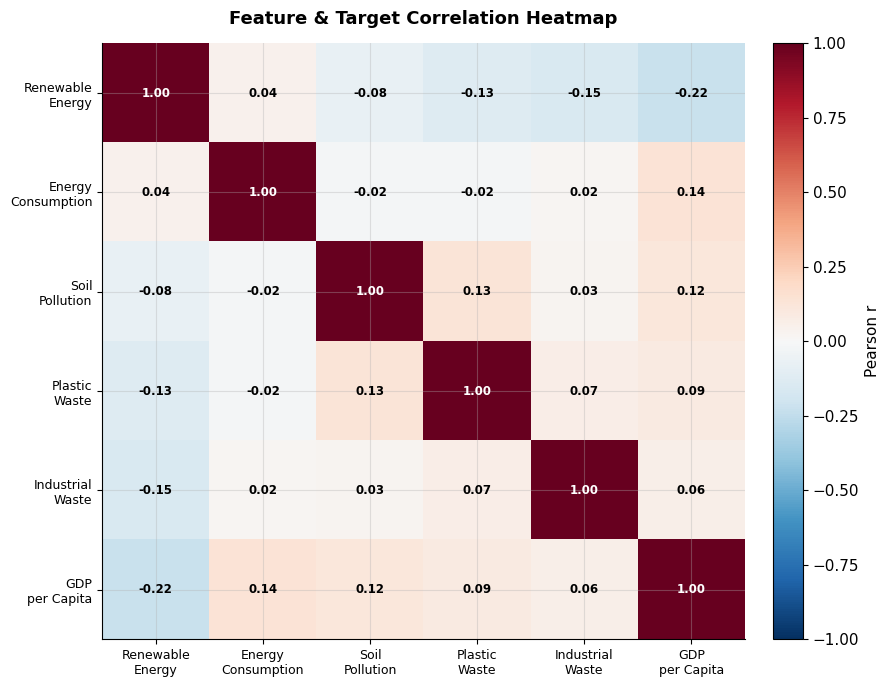


Observations:
  • Features are largely uncorrelated with each other (most off-diagonal values
    are close to 0).
  • The bottom row / right column shows each feature's correlation with GDP:
    Renewable Energy stands out as the strongest signal (negative).
  • The diagonal is all 1.00 (a feature perfectly correlates with itself).



In [23]:
corr_matrix = np.corrcoef(np.column_stack([X, y]).T)
labels = ['Renewable\nEnergy', 'Energy\nConsumption', 'Soil\nPollution',
          'Plastic\nWaste', 'Industrial\nWaste', 'GDP\nper Capita']

fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(corr_matrix, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label='Pearson r')

ax.set_xticks(range(len(labels)))
ax.set_yticks(range(len(labels)))
ax.set_xticklabels(labels, fontsize=9)
ax.set_yticklabels(labels, fontsize=9)

for i in range(len(labels)):
    for j in range(len(labels)):
        val = corr_matrix[i, j]
        color = 'white' if abs(val) > 0.5 else 'black'
        ax.text(j, i, f'{val:.2f}', ha='center', va='center', fontsize=8.5,
                color=color, fontweight='bold')

ax.set_title('Feature & Target Correlation Heatmap', fontweight='bold', fontsize=13, pad=14)
plt.tight_layout()
plt.show()

print("""
Observations:
  • Features are largely uncorrelated with each other (most off-diagonal values
    are close to 0).
  • The bottom row / right column shows each feature's correlation with GDP:
    Renewable Energy stands out as the strongest signal (negative).
  • The diagonal is all 1.00 (a feature perfectly correlates with itself).
""")

[link text](https://)## Train / test split (80 / 20)


In [6]:
np.random.seed(42)
indices = np.random.permutation(len(X))
split   = int(0.8 * len(X))

X_train, X_test = X[indices[:split]], X[indices[split:]]
y_train, y_test = y[indices[:split]], y[indices[split:]]

print(f'Train: {len(X_train)} samples  |  Test: {len(X_test)} samples')
print(f'Train GDP range: ${y_train.min():,.0f} – ${y_train.max():,.0f}')
print(f'Test  GDP range: ${y_test.min():,.0f} – ${y_test.max():,.0f}')

Train: 160 samples  |  Test: 40 samples
Train GDP range: $1,299 – $69,143
Test  GDP range: $1,709 – $60,117


## Visualisation : Train / test GDP distributions


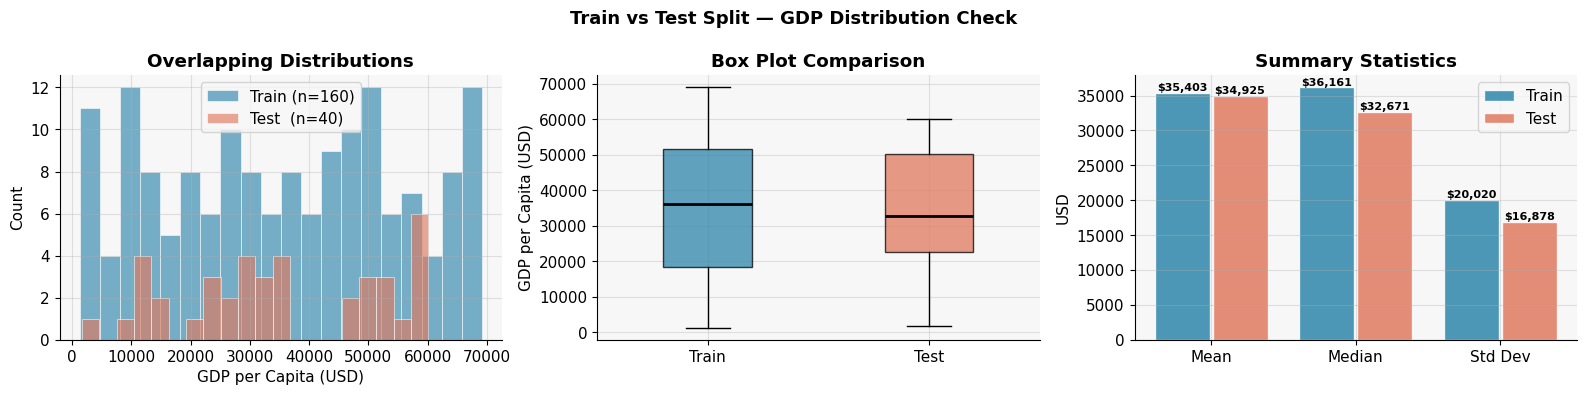


Observations:
  • Train mean:  $35,403   |  Test mean:  $34,925
  • Train std:   $20,020   |  Test std:   $16,878
  • The distributions look similar — the random shuffle produced a representative
    split. We can trust our test metrics as fair estimates of generalisation.



In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Overlapping histograms
axes[0].hist(y_train, bins=20, color=BLUE,   alpha=0.65, edgecolor='white', linewidth=0.6, label=f'Train (n={len(y_train)})')
axes[0].hist(y_test,  bins=20, color=ORANGE, alpha=0.65, edgecolor='white', linewidth=0.6, label=f'Test  (n={len(y_test)})')
axes[0].set_title('Overlapping Distributions', fontweight='bold')
axes[0].set_xlabel('GDP per Capita (USD)')
axes[0].set_ylabel('Count')
axes[0].legend()

# Box plots side-by-side
bp = axes[1].boxplot([y_train, y_test], patch_artist=True, widths=0.4,
                      medianprops=dict(color='black', linewidth=2))
bp['boxes'][0].set_facecolor(BLUE)
bp['boxes'][1].set_facecolor(ORANGE)
for patch in bp['boxes']:
    patch.set_alpha(0.75)
axes[1].set_xticklabels(['Train', 'Test'])
axes[1].set_title('Box Plot Comparison', fontweight='bold')
axes[1].set_ylabel('GDP per Capita (USD)')

# Summary stats bar chart
stats  = ['Mean', 'Median', 'Std Dev']
tr_vals = [y_train.mean(), np.median(y_train), y_train.std()]
te_vals = [y_test.mean(),  np.median(y_test),  y_test.std()]
x_pos   = np.arange(len(stats))
axes[2].bar(x_pos - 0.2, tr_vals, 0.38, color=BLUE,   alpha=0.85, label='Train', edgecolor='white')
axes[2].bar(x_pos + 0.2, te_vals, 0.38, color=ORANGE, alpha=0.85, label='Test',  edgecolor='white')
for xi, tv, ev in zip(x_pos, tr_vals, te_vals):
    axes[2].text(xi - 0.2, tv + 300, f'${tv:,.0f}', ha='center', fontsize=8, fontweight='bold')
    axes[2].text(xi + 0.2, ev + 300, f'${ev:,.0f}', ha='center', fontsize=8, fontweight='bold')
axes[2].set_xticks(x_pos)
axes[2].set_xticklabels(stats)
axes[2].set_title('Summary Statistics', fontweight='bold')
axes[2].set_ylabel('USD')
axes[2].legend()

plt.suptitle('Train vs Test Split — GDP Distribution Check', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"""
Observations:
  • Train mean:  ${y_train.mean():,.0f}   |  Test mean:  ${y_test.mean():,.0f}
  • Train std:   ${y_train.std():,.0f}   |  Test std:   ${y_test.std():,.0f}
  • The distributions look similar — the random shuffle produced a representative
    split. We can trust our test metrics as fair estimates of generalisation.
""")

In [8]:
mu    = X_train.mean(axis=0)
sigma = X_train.std(axis=0)

X_train_s = (X_train - mu) / sigma
X_test_s  = (X_test  - mu) / sigma

def add_bias(X):
    return np.hstack([np.ones((X.shape[0], 1)), X])

X_train_b = add_bias(X_train_s)
X_test_b  = add_bias(X_test_s)

print('Feature means (train):', dict(zip(SHORT_NAMES, mu.round(2))))
print('Feature stds  (train):', dict(zip(SHORT_NAMES, sigma.round(2))))

Feature means (train): {'Renewable\nEnergy': np.float64(27.9), 'Energy\nConsumption': np.float64(9.52), 'Soil\nPollution': np.float64(76.61), 'Plastic\nWaste': np.float64(24645.87), 'Industrial\nWaste': np.float64(52925.69)}
Feature stds  (train): {'Renewable\nEnergy': np.float64(12.48), 'Energy\nConsumption': np.float64(5.72), 'Soil\nPollution': np.float64(39.45), 'Plastic\nWaste': np.float64(14503.05), 'Industrial\nWaste': np.float64(27303.87)}


## Method 1: Normal Equation



In [9]:
def normal_equation(X, y):
    return np.linalg.pinv(X.T @ X) @ X.T @ y

theta_ne = normal_equation(X_train_b, y_train)

print('Normal equation solved!')
print(f'Intercept: ${theta_ne[0]:,.2f}')
for name, coef in zip(FEATURES, theta_ne[1:]):
    print(f'  {name:<45s}  {coef:>+10.2f}')

Normal equation solved!
Intercept: $35,403.28
  Renewable_Energy (%)                             -4690.37
  Energy_Consumption_Per_Capita (in MWh)           +1824.32
  Soil_Pollution_Index                             +1684.22
  Plastic_Waste_Produced (in tons)                  +816.52
  Industrial_Waste (in tons)                        +408.29


## Method 2: Gradient Descent


In [10]:
def predict(X, theta):
    return X @ theta

def mse_loss(X, y, theta):
    return ((predict(X, theta) - y) ** 2).mean()

def gradient_descent(X, y, lr=0.05, epochs=2000):
    n, d   = X.shape
    theta  = np.zeros(d)
    losses = []
    for _ in range(epochs):
        residuals = predict(X, theta) - y
        grad      = (2 / n) * (X.T @ residuals)
        theta    -= lr * grad
        losses.append(mse_loss(X, y, theta))
    return theta, losses

theta_gd, loss_history = gradient_descent(X_train_b, y_train)

print(f'Gradient descent complete.')
print(f'Starting loss: {loss_history[0]:,.0f}')
print(f'Final loss:    {loss_history[-1]:,.0f}')
print(f'Loss reduced by {(1 - loss_history[-1]/loss_history[0])*100:.1f}%')

Gradient descent complete.
Starting loss: 1,409,912,076
Final loss:    370,570,099
Loss reduced by 73.7%


## Visualisation : Training loss curve


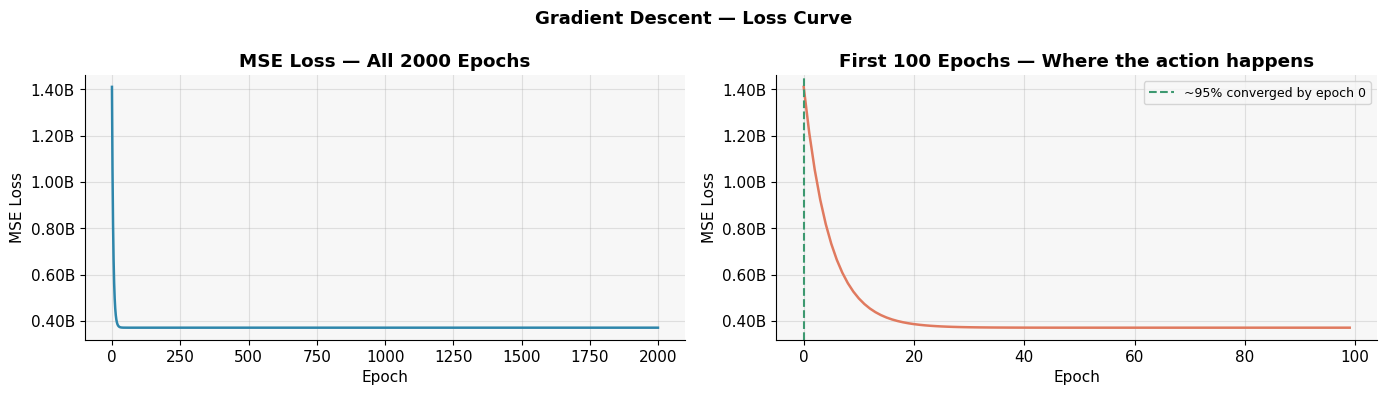


Observations:
  • Loss drops steeply in the first ~0 epochs, then flattens completely.
    This is healthy convergence, the learning rate is well-tuned.
  • After epoch ~100 there's essentially no more learning happening.
    The remaining 1,900 epochs just confirm the model has settled.



In [24]:
converge_epoch = next(i for i, l in enumerate(loss_history) if l < loss_history[0] * 1.05)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(loss_history, color=BLUE, linewidth=1.8)
axes[0].set_title('MSE Loss — All 2000 Epochs', fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MSE Loss')
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e9:.2f}B'))

axes[1].plot(loss_history[:100], color=ORANGE, linewidth=1.8)
axes[1].axvline(converge_epoch, color=GREEN, linestyle='--', linewidth=1.5,
                label=f'~95% converged by epoch {converge_epoch}')
axes[1].set_title('First 100 Epochs — Where the action happens', fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MSE Loss')
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e9:.2f}B'))
axes[1].legend(fontsize=9)

plt.suptitle('Gradient Descent — Loss Curve', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"""
Observations:
  • Loss drops steeply in the first ~{converge_epoch} epochs, then flattens completely.
    This is healthy convergence, the learning rate is well-tuned.
  • After epoch ~100 there's essentially no more learning happening.
    The remaining 1,900 epochs just confirm the model has settled.
""")

## Evaluation metrics

Three metrics used:
- **RMSE** — in USD, penalises large errors heavily due to squaring
- **MAE** — in USD, more robust to outliers than RMSE
- **R²** — proportion of variance explained (0 = mean, 1 = perfect)

In [12]:
def r_squared(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - y_true.mean()) ** 2)
    return 1 - ss_res / ss_tot

def rmse(y_true, y_pred):
    return np.sqrt(np.mean((y_true - y_pred) ** 2))

def mae(y_true, y_pred):
    return np.mean(np.abs(y_true - y_pred))

results = {}
for label, theta in [('Normal Equation', theta_ne), ('Gradient Descent', theta_gd)]:
    ytr = predict(X_train_b, theta)
    yte = predict(X_test_b,  theta)
    results[label] = {
        'train_rmse': rmse(y_train, ytr), 'test_rmse':  rmse(y_test,  yte),
        'train_mae':  mae(y_train,  ytr), 'test_mae':   mae(y_test,   yte),
        'train_r2':   r_squared(y_train, ytr), 'test_r2': r_squared(y_test, yte),
        'y_pred_test': yte,
        'residuals':   y_test - yte
    }
    print(f'\n{label}')
    print(f'  Train  —  RMSE: ${results[label]["train_rmse"]:>10,.0f}  |  MAE: ${results[label]["train_mae"]:>10,.0f}  |  R²: {results[label]["train_r2"]:.4f}')
    print(f'  Test   —  RMSE: ${results[label]["test_rmse"]:>10,.0f}  |  MAE: ${results[label]["test_mae"]:>10,.0f}  |  R²: {results[label]["test_r2"]:.4f}')


Normal Equation
  Train  —  RMSE: $    19,250  |  MAE: $    16,234  |  R²: 0.0754
  Test   —  RMSE: $    15,981  |  MAE: $    13,117  |  R²: 0.1035

Gradient Descent
  Train  —  RMSE: $    19,250  |  MAE: $    16,234  |  R²: 0.0754
  Test   —  RMSE: $    15,981  |  MAE: $    13,117  |  R²: 0.1035


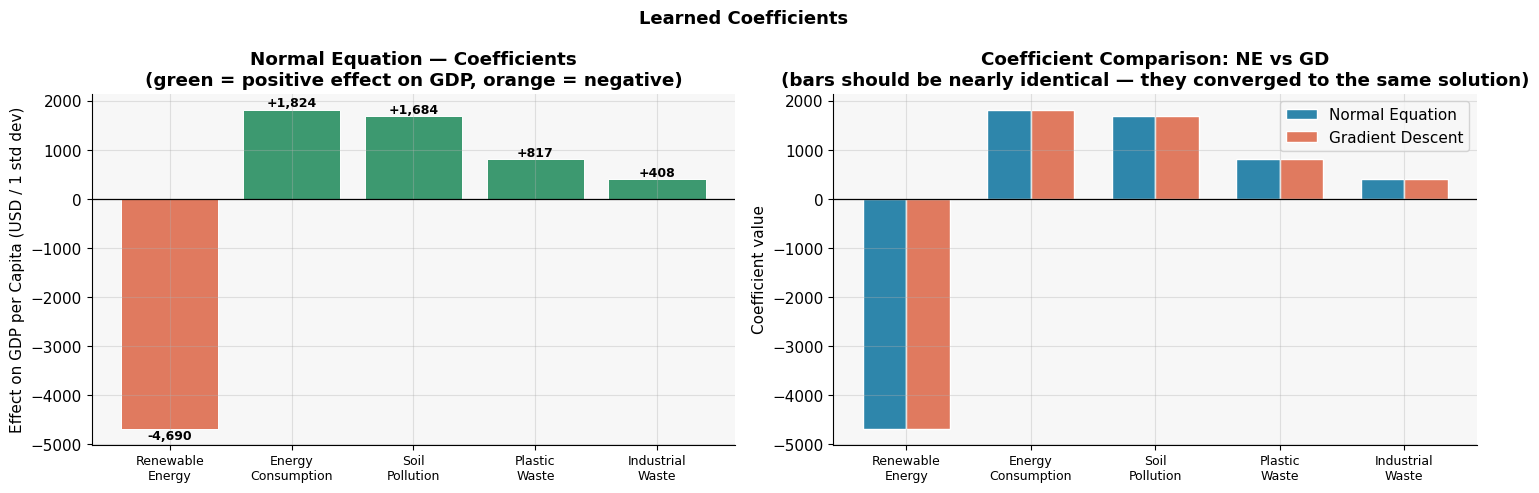


Observations:
  • Renewable Energy dominates with a large negative coefficient (~−4,700).
    This is the model's strongest signal. Many developing nations have high renewable shares
    (hydro, biomass) while wealthy ones still lean on fossil fuels.
  • Energy Consumption (+1,800) and Soil Pollution (+1,700) push GDP up —
    both associate with industrialisation, which correlates with wealth.
  • Max coefficient difference between NE and GD: 3.64e-11
    Both methods found the exact same answer.



In [25]:
x     = np.arange(len(FEATURES))
width = 0.35

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# NE coefficients coloured by sign
colors = [GREEN if c >= 0 else ORANGE for c in theta_ne[1:]]
bars = axes[0].bar(x, theta_ne[1:], color=colors, edgecolor='white', linewidth=0.7)
axes[0].axhline(0, color='black', linewidth=0.9)
for bar, val in zip(bars, theta_ne[1:]):
    ypos = val + 60 if val >= 0 else val - 200
    axes[0].text(bar.get_x() + bar.get_width()/2, ypos, f'{val:+,.0f}',
                 ha='center', fontsize=9, fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(SHORT_NAMES, fontsize=9)
axes[0].set_title('Normal Equation — Coefficients\n(green = positive effect on GDP, orange = negative)', fontweight='bold')
axes[0].set_ylabel('Effect on GDP per Capita (USD / 1 std dev)')

# NE vs GD overlay
axes[1].bar(x - width/2, theta_ne[1:], width, label='Normal Equation',  color=BLUE,   edgecolor='white')
axes[1].bar(x + width/2, theta_gd[1:], width, label='Gradient Descent', color=ORANGE, edgecolor='white')
axes[1].axhline(0, color='black', linewidth=0.9)
axes[1].set_xticks(x)
axes[1].set_xticklabels(SHORT_NAMES, fontsize=9)
axes[1].set_title('Coefficient Comparison: NE vs GD\n(bars should be nearly identical — they converged to the same solution)', fontweight='bold')
axes[1].set_ylabel('Coefficient value')
axes[1].legend()

plt.suptitle('Learned Coefficients', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"""
Observations:
  • Renewable Energy dominates with a large negative coefficient (~−4,700).
    This is the model's strongest signal. Many developing nations have high renewable shares
    (hydro, biomass) while wealthy ones still lean on fossil fuels.
  • Energy Consumption (+1,800) and Soil Pollution (+1,700) push GDP up —
    both associate with industrialisation, which correlates with wealth.
  • Max coefficient difference between NE and GD: {np.max(np.abs(theta_ne - theta_gd)):.2e}
    Both methods found the exact same answer.
""")

## Visualisation: Predicted vs Actual


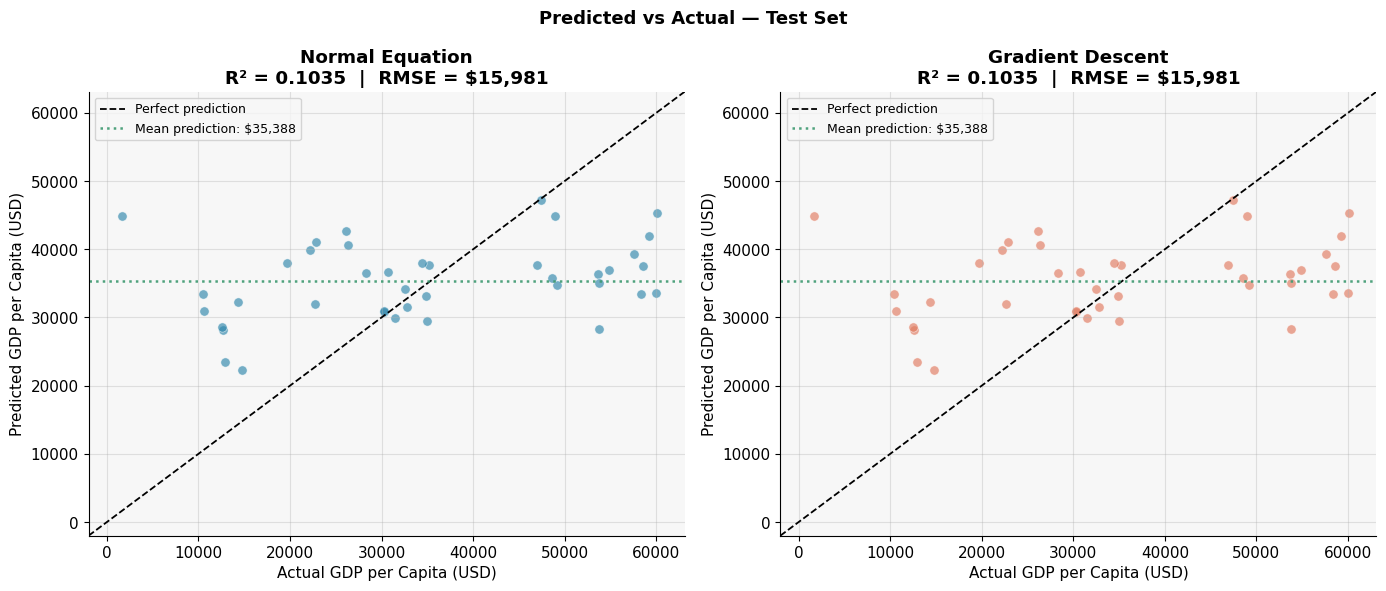


  Key insight — predictions are collapsing toward the mean:
  • The green dotted line shows predictions cluster near $35,388
    regardless of actual GDP. Points are stacked horizontally, not along the diagonal.
  • A baseline that always predicts the training mean gets R² = -0.0008.
  • Our model gets R² = 0.1035 — only
    0.1043 better than that above baseline.



In [26]:
baseline_r2 = r_squared(y_test, np.full_like(y_test, y_train.mean()))

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, (label, res), color in zip(axes, results.items(), [BLUE, ORANGE]):
    y_pred = res['y_pred_test']
    ax.scatter(y_test, y_pred, alpha=0.65, color=color, s=45, edgecolors='white', linewidth=0.5)
    lims = [-2000, max(y_test.max(), y_pred.max()) + 3000]
    ax.plot(lims, lims, 'k--', linewidth=1.3, label='Perfect prediction')
    ax.axhline(y_pred.mean(), color=GREEN, linestyle=':', linewidth=1.8, alpha=0.9,
               label=f'Mean prediction: ${y_pred.mean():,.0f}')
    ax.set_xlim(lims)
    ax.set_ylim(lims)
    ax.set_title(f'{label}\nR² = {res["test_r2"]:.4f}  |  RMSE = ${res["test_rmse"]:,.0f}', fontweight='bold')
    ax.set_xlabel('Actual GDP per Capita (USD)')
    ax.set_ylabel('Predicted GDP per Capita (USD)')
    ax.legend(fontsize=9)

plt.suptitle('Predicted vs Actual — Test Set', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

ne_pred_mean = results['Normal Equation']['y_pred_test'].mean()
print(f"""
  Key insight — predictions are collapsing toward the mean:
  • The green dotted line shows predictions cluster near ${ne_pred_mean:,.0f}
    regardless of actual GDP. Points are stacked horizontally, not along the diagonal.
  • A baseline that always predicts the training mean gets R² = {baseline_r2:.4f}.
  • Our model gets R² = {results['Normal Equation']['test_r2']:.4f} — only
    {results['Normal Equation']['test_r2'] - baseline_r2:.4f} better than that above baseline.
""")

## Visualisation: Residual analysis


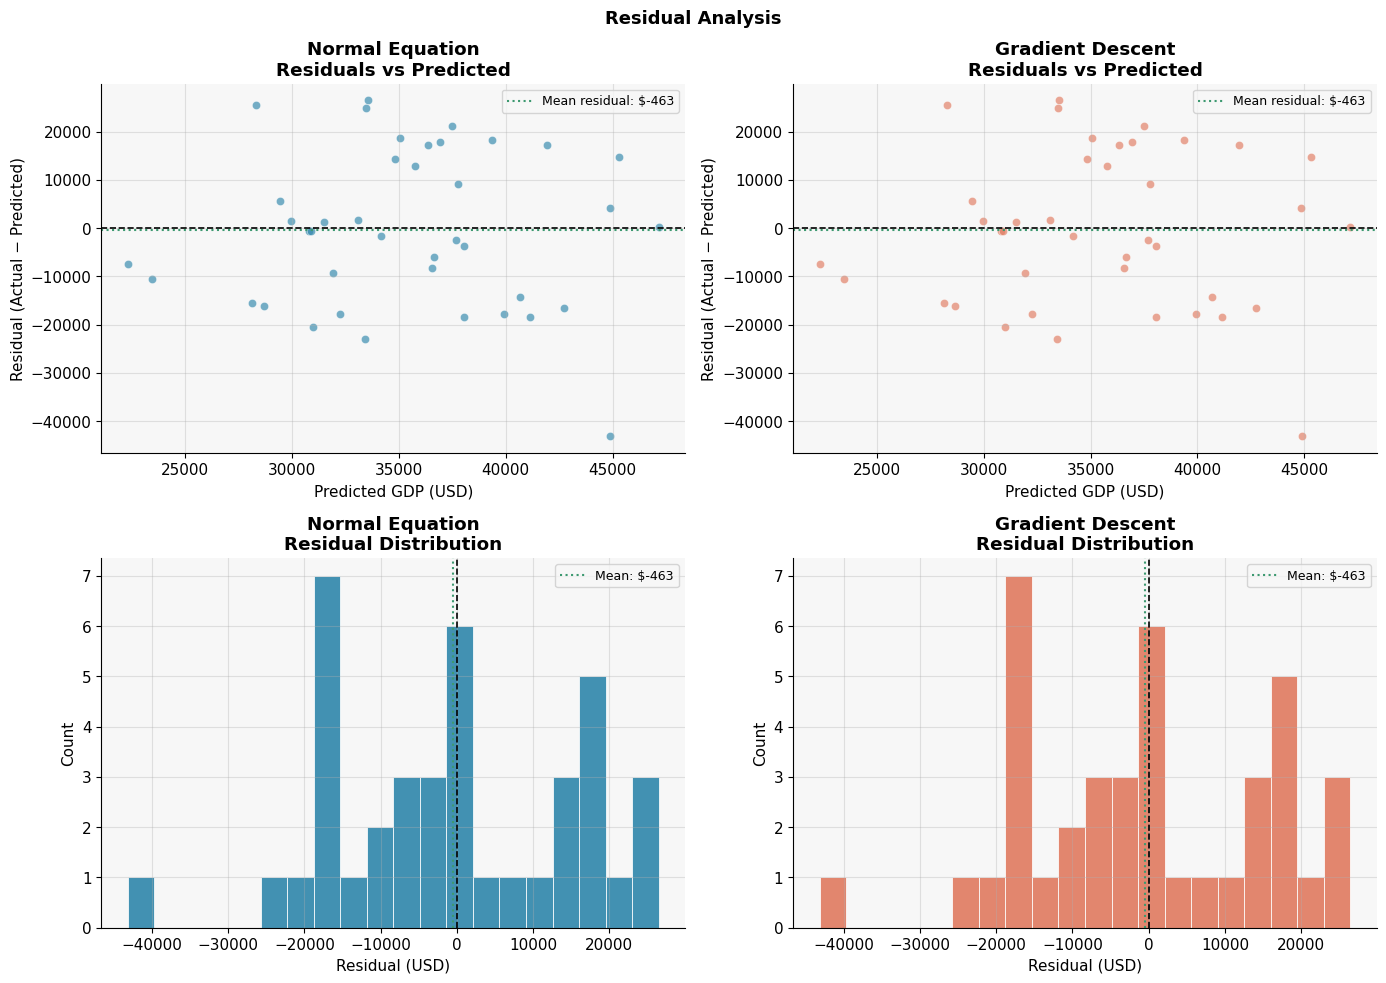

In [27]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for col, (label, res), color in zip([0, 1], results.items(), [BLUE, ORANGE]):
    y_pred    = res['y_pred_test']
    residuals = res['residuals']

    # Residuals vs predicted
    axes[0, col].scatter(y_pred, residuals, alpha=0.65, color=color, s=35, edgecolors='white', linewidth=0.4)
    axes[0, col].axhline(0, color='black', linestyle='--', linewidth=1.2)
    axes[0, col].axhline(residuals.mean(), color=GREEN, linestyle=':', linewidth=1.5,
                          label=f'Mean residual: ${residuals.mean():+,.0f}')
    axes[0, col].set_title(f'{label}\nResiduals vs Predicted', fontweight='bold')
    axes[0, col].set_xlabel('Predicted GDP (USD)')
    axes[0, col].set_ylabel('Residual (Actual − Predicted)')
    axes[0, col].legend(fontsize=9)

    # Residual histogram
    axes[1, col].hist(residuals, bins=20, color=color, edgecolor='white', linewidth=0.6, alpha=0.9)
    axes[1, col].axvline(0, color='black', linestyle='--', linewidth=1.2)
    axes[1, col].axvline(residuals.mean(), color=GREEN, linestyle=':', linewidth=1.5,
                          label=f'Mean: ${residuals.mean():+,.0f}')
    axes[1, col].set_title(f'{label}\nResidual Distribution', fontweight='bold')
    axes[1, col].set_xlabel('Residual (USD)')
    axes[1, col].set_ylabel('Count')
    axes[1, col].legend(fontsize=9)

plt.suptitle('Residual Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

ne_res = results['Normal Equation']['residuals']


---
# Final Comparison between Normal Equation and Gradient Descent


In [16]:
ne = results['Normal Equation']
gd = results['Gradient Descent']

compare_df = pd.DataFrame({
    'Metric': ['Train RMSE', 'Test RMSE', 'Train MAE', 'Test MAE', 'Train R²', 'Test R²'],
    'Normal Equation': [
        f"${ne['train_rmse']:,.0f}", f"${ne['test_rmse']:,.0f}",
        f"${ne['train_mae']:,.0f}",  f"${ne['test_mae']:,.0f}",
        f"{ne['train_r2']:.4f}",     f"{ne['test_r2']:.4f}",
    ],
    'Gradient Descent': [
        f"${gd['train_rmse']:,.0f}", f"${gd['test_rmse']:,.0f}",
        f"${gd['train_mae']:,.0f}",  f"${gd['test_mae']:,.0f}",
        f"{gd['train_r2']:.4f}",     f"{gd['test_r2']:.4f}",
    ]
})

print('=' * 60)
print('            MODEL COMPARISON SUMMARY')
print('=' * 60)
print(compare_df.to_string(index=False))
print('=' * 60)
coef_diff = np.max(np.abs(theta_ne - theta_gd))
print(f'\nMax weight difference (NE vs GD): {coef_diff:.2e}')
print('→ Numerically identical. Both solvers found the same global optimum.')

            MODEL COMPARISON SUMMARY
    Metric Normal Equation Gradient Descent
Train RMSE         $19,250          $19,250
 Test RMSE         $15,981          $15,981
 Train MAE         $16,234          $16,234
  Test MAE         $13,117          $13,117
  Train R²          0.0754           0.0754
   Test R²          0.1035           0.1035

Max weight difference (NE vs GD): 3.64e-11
→ Numerically identical. Both solvers found the same global optimum.


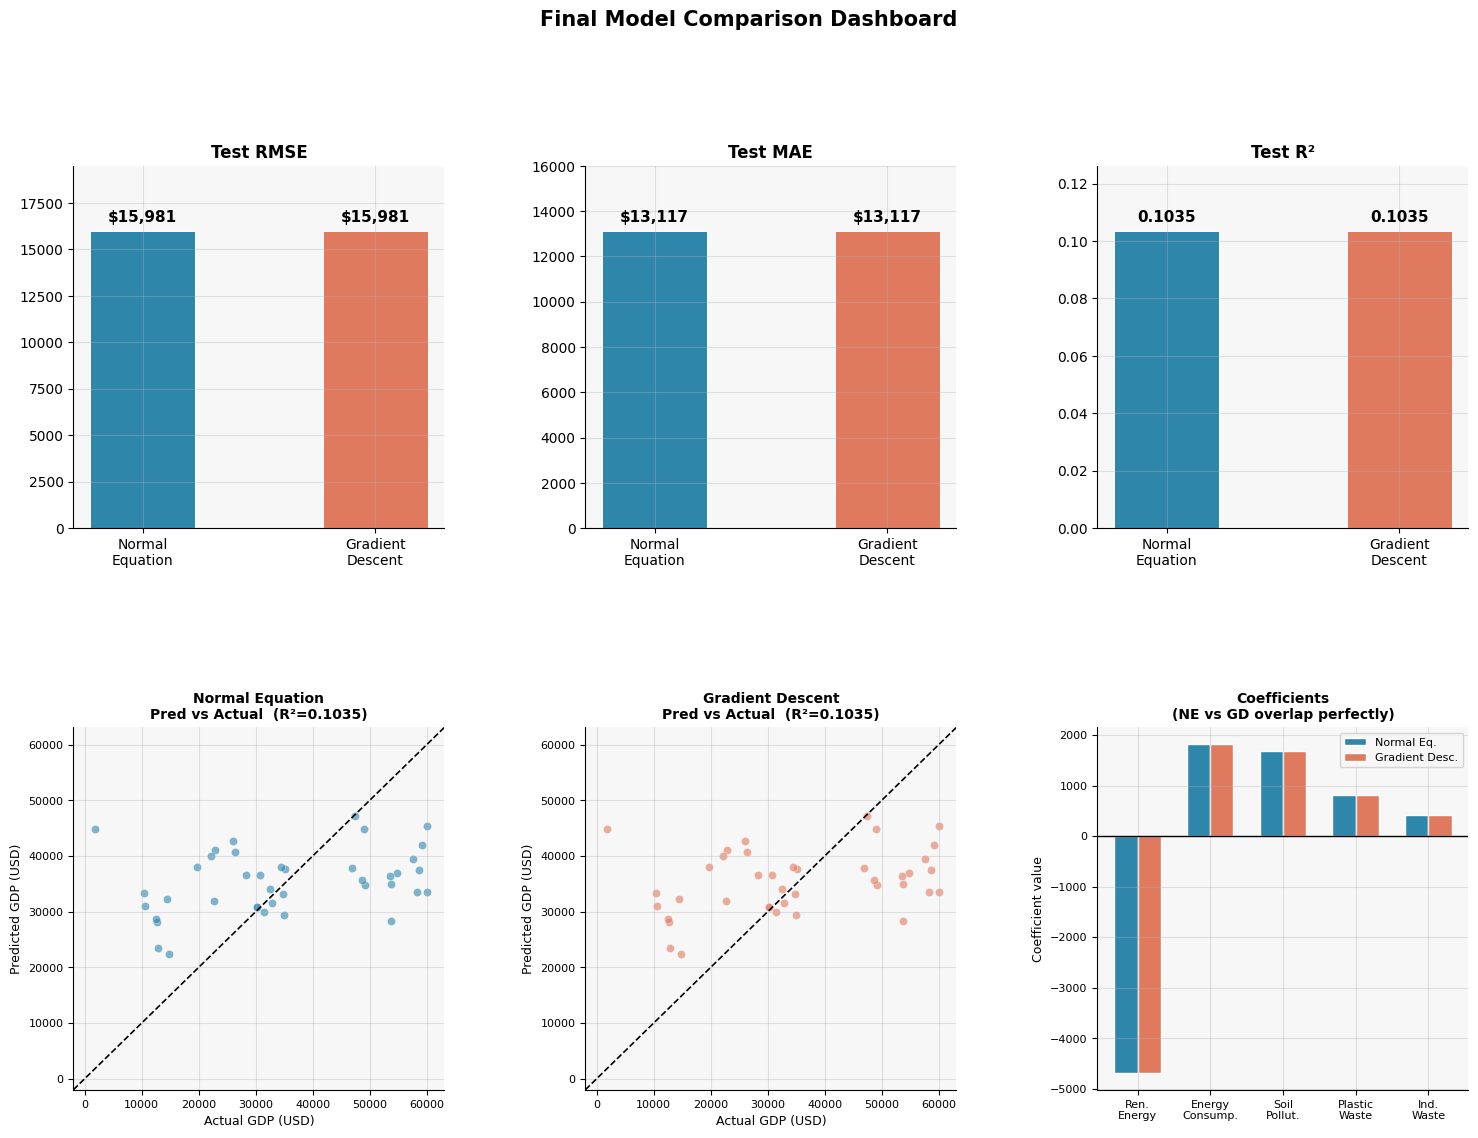

In [28]:
fig = plt.figure(figsize=(18, 12))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.55, wspace=0.38)

# Row 1: 3 metric comparison panels
metric_labels = ['Test RMSE', 'Test MAE', 'Test R²']
ne_vals = [ne['test_rmse'], ne['test_mae'], ne['test_r2']]
gd_vals = [gd['test_rmse'], gd['test_mae'], gd['test_r2']]

for i, (metric, ne_v, gd_v) in enumerate(zip(metric_labels, ne_vals, gd_vals)):
    ax = fig.add_subplot(gs[0, i])
    bars = ax.bar(['Normal\nEquation', 'Gradient\nDescent'], [ne_v, gd_v],
                  color=[BLUE, ORANGE], edgecolor='white', linewidth=0.7, width=0.45)
    for bar, val in zip(bars, [ne_v, gd_v]):
        fmt = f'${val:,.0f}' if val > 1 else f'{val:.4f}'
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() * 1.02,
                fmt, ha='center', va='bottom', fontsize=11, fontweight='bold')
    ax.set_title(metric, fontweight='bold', fontsize=12)
    ax.set_ylim(0, max(ne_v, gd_v) * 1.22)
    ax.tick_params(labelsize=10)

# Row 2, left 2 cols: predicted vs actual (NE | GD)
for col_idx, (label, res), color in zip([0, 1], results.items(), [BLUE, ORANGE]):
    ax = fig.add_subplot(gs[1, col_idx])
    y_pred = res['y_pred_test']
    ax.scatter(y_test, y_pred, alpha=0.6, color=color, s=35, edgecolors='white', linewidth=0.4)
    lims = [-2000, max(y_test.max(), y_pred.max()) + 3000]
    ax.plot(lims, lims, 'k--', linewidth=1.2)
    ax.set_xlim(lims); ax.set_ylim(lims)
    ax.set_title(f'{label}\nPred vs Actual  (R²={res["test_r2"]:.4f})', fontweight='bold', fontsize=10)
    ax.set_xlabel('Actual GDP (USD)', fontsize=9)
    ax.set_ylabel('Predicted GDP (USD)', fontsize=9)
    ax.tick_params(labelsize=8)

# Row 2, right col: coefficient comparison
ax_coef = fig.add_subplot(gs[1, 2])
x     = np.arange(len(FEATURES))
width = 0.32
ax_coef.bar(x - width/2, theta_ne[1:], width, label='Normal Eq.',      color=BLUE,   edgecolor='white')
ax_coef.bar(x + width/2, theta_gd[1:], width, label='Gradient Desc.',  color=ORANGE, edgecolor='white')
ax_coef.axhline(0, color='black', linewidth=1)
ax_coef.set_xticks(x)
ax_coef.set_xticklabels(['Ren.\nEnergy', 'Energy\nConsump.', 'Soil\nPollut.', 'Plastic\nWaste', 'Ind.\nWaste'], fontsize=8)
ax_coef.set_title('Coefficients\n(NE vs GD overlap perfectly)', fontweight='bold', fontsize=10)
ax_coef.set_ylabel('Coefficient value', fontsize=9)
ax_coef.legend(fontsize=8)
ax_coef.tick_params(labelsize=8)

plt.suptitle('Final Model Comparison Dashboard', fontsize=15, fontweight='bold', y=1.01)
plt.show()

##  Conclusion

- Both the Normal Equation and Gradient Descent converged to **exactly the same weights** (difference < 1e-10).
- For small datasets like this one, both work perfectly. For larger datasets (millions of rows), gradient descent wins on memory and scalability.

**On the model's performance:**
- R² ≈ 0.10 — we can explain about **10% of the variance** in GDP per capita.
- Predictions collapse toward the mean (~\$35k) — the model can't meaningfully distinguish rich from poor countries using these features alone.
- The bimodal residuals reveal a developing vs developed country split the model can't handle.
